# **0. Описание ноутбука**

**Целью ноутбука** является выбрать среди базовых моделей наилучшую модель для дальнейшего его развития и использования

**Содержание:**
1. Подготовка датасета, библиотек, функций и переменных;
2. Обучение моделей;
3. Общей итог работы.

**Обучение и сравнение моделей:**
В ноутбуке присуствуют такие модели как:
```
Логистическая регрессия, SVM, Дерево значений, Случайный лес, Стекинг, CatBoost
```
Для каждой модели будут представлены 3 варианта данных для сравнения и подтверждения какая лучше на практике:

1.   Без BMI, но с Ростом и Весом
2.   С BMI, но без Роста и Веса
3.   Без BMI и без Роста и Веса

Для сравнение обратим внимание на такие метрики:
- F1-Score
- Log Loss
- Roc-auc
- Время обучения
- Precision
- Recall
- Accuracy


Важными метриками для нас являются:
- **F1-Score** из-за средних показателей Precision и Recall, а также из-за в отличие от Accuracy более надежен при дисбалансе классов;
- **Время обучения**, т.к. показывает скорость обучения;
- **Log Loss** для показа насколько можно довериться вроятностям модели;
- **ROC-AUC** для показа способности модели разделять классы.


# **1.1. Подготовка данных и инструментов**

*Описание импортов библиотек и готовых данных и инструментов*

## Загрузка и обработка данных

In [354]:
from pathlib import Path
import sys, os

REPO_DIR = 'Multiclass_prediction_of_obesity_risk'
REPO_URL = 'https://github.com/AlexTilta/Multiclass_prediction_of_obesity_risk.git'

if not os.path.isdir(REPO_DIR):
    print("Репозиторий не найден. Клонирование и установка зависимостей...")
    !git clone {REPO_URL}

    !pip -q install -r {REPO_DIR}/requirements.txt
else:
    print(f"Репозиторий '{REPO_DIR}' уже склонирован.")

%cd {REPO_DIR}

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


from src.utils import load_csv

df_original = load_csv('prepared_data.csv', 'data')
df_original.head()

Репозиторий 'Multiclass_prediction_of_obesity_risk' уже склонирован.
/content/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk/Multiclass_prediction_of_obesity_risk


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0000,1.6200,64.0000,yes,no,Sometimes,3,Sometimes,no,1-2,no,0,3-5,no,Public_Transportation,Normal_Weight,24.3865
1,Female,21.0000,1.5200,56.0000,yes,no,Always,3,Sometimes,yes,>2,yes,4-5,0-2,Sometimes,Public_Transportation,Normal_Weight,24.2382
2,Male,23.0000,1.8000,77.0000,yes,no,Sometimes,3,Sometimes,no,1-2,no,2-4,3-5,Frequently,Public_Transportation,Normal_Weight,23.7654
3,Male,27.0000,1.8000,87.0000,no,no,Always,3,Sometimes,no,1-2,no,2-4,0-2,Frequently,Walking,Overweight,26.8519
4,Male,22.0000,1.7800,89.8000,no,no,Sometimes,1-2,Sometimes,no,1-2,no,0,0-2,Sometimes,Public_Transportation,Overweight,28.3424


 ## Установка библиотек

In [355]:
!pip show catboost || pip install catboost
!pip show phik || pip install phik

Name: catboost
Version: 1.2.8
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
Name: phik
Version: 0.12.5
Summary: Phi_K correlation analyzer library
Home-page: 
Author: 
Author-email: "KPMG N.V. The Netherlands" <kave@kpmg.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, matplotlib, numpy, pandas, scipy
Required-by: 


## Библиотеки

In [356]:
# Общие библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import optuna
import warnings
from matplotlib import pyplot as plt
from sklearn.exceptions import ConvergenceWarning

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score # <-- ДОБАВЛЕНО
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, PolynomialFeatures
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, log_loss, roc_auc_score
)
# Библиотеки для отчетов
import json
import time
from IPython.display import display

# Утилиты
import joblib
import warnings
warnings.filterwarnings('ignore')
from phik import phik_matrix


# Библиотеки моделей или для конкретных моделей
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier
)
from catboost import CatBoostClassifier, Pool, cv

# **1.2. Настройка датасета**

*Описание констант для датасета(для быстрой настройки) и преобразования категориальных данных в числовые*

## Константы (для отчетов и редактирования наименований признаков)

In [357]:
# Целева переменная
TARGET_COLUMN = 'NObeyesdad'

# Константы для разных видов данных
ANTHROPOMETRICS = ['Height', 'Weight', 'BMI']

COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY = [TARGET_COLUMN, 'BMI']
COLUMNS_TO_DROP_BMI_ONLY = [TARGET_COLUMN, 'Height', 'Weight']
COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED = [TARGET_COLUMN] + ANTHROPOMETRICS

## Преобразование данных для большинство моделей

In [358]:
# Копирование данных (оригинал пригодится для CatBoost)
df_transformed = df_original.copy()

# Подготовка для преобразования строковых признаков
caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_transformed['CAEC'] = df_transformed['CAEC'].replace(caec_calc_map)
df_transformed['CALC'] = df_transformed['CALC'].replace(caec_calc_map)

fcvc_map = {'no': 0, 'Sometimes': 1, 'Always': 2}
df_transformed['FCVC'] = df_transformed['FCVC'].replace(fcvc_map)

ncp_map = {'1-2': 1.5, '3': 3.0, '>3': 3.5}
df_transformed['NCP'] = df_transformed['NCP'].replace(ncp_map)

ch2o_map = {'<1': 0.5, 'Sometimes': 1.0, '1-2': 1.5, '>2': 3.0}
df_transformed['CH2O'] = df_transformed['CH2O'].replace(ch2o_map)

faf_tue_map = {'0': 0, 'no': 0, '0-2': 1, '1-2': 1, '2-4': 3,
               '3-5': 4, '4-5': 4, '>5': 5}
df_transformed['FAF'] = df_transformed['FAF'].replace(faf_tue_map)
df_transformed['TUE'] = df_transformed['TUE'].replace(faf_tue_map)

yes_no_map = {'yes': 1.0, 'no': 0.0}
df_transformed['family_history_with_overweight'] = df_transformed['family_history_with_overweight'].replace(yes_no_map)
df_transformed['FAVC'] = df_transformed['FAVC'].replace(yes_no_map)
df_transformed['SMOKE'] = df_transformed['SMOKE'].replace(yes_no_map)
df_transformed['SCC'] = df_transformed['SCC'].replace(yes_no_map)

gender_map = {'Male': 1.0, 'Female': 0.0}
df_transformed['Gender'] = df_transformed['Gender'].replace(gender_map)

# Преобразование
mtrans_le = LabelEncoder()
df_transformed['MTRANS'] = mtrans_le.fit_transform(df_transformed['MTRANS']).astype(float)

df = df_transformed

INT_COLUMNS = ['FCVC', 'CAEC', 'FAF', 'TUE', 'CALC']
INT_COLUMNS_ADJUSTED = [col for col in INT_COLUMNS if col in df.columns]

for col in INT_COLUMNS_ADJUSTED:
    df[col] = df[col].astype('Int64')

EXCLUDE_COLUMNS = [TARGET_COLUMN] + INT_COLUMNS_ADJUSTED

COLUMNS_TO_FLOAT = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

for col in COLUMNS_TO_FLOAT:
    try:
        df[col] = df[col].astype(float)
    except Exception as e:
        pass

# Вывод
print(df.dtypes)
df

Gender                            float64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight    float64
FAVC                              float64
FCVC                                Int64
NCP                               float64
CAEC                                Int64
SMOKE                             float64
CH2O                              float64
SCC                               float64
FAF                                 Int64
TUE                                 Int64
CALC                                Int64
MTRANS                            float64
NObeyesdad                         object
BMI                               float64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0.0000,21.0000,1.6200,64.0000,1.0000,0.0000,1,3.0000,1,0.0000,1.5000,0.0000,0,4,0,3.0000,Normal_Weight,24.3865
1,0.0000,21.0000,1.5200,56.0000,1.0000,0.0000,2,3.0000,1,1.0000,3.0000,1.0000,4,1,1,3.0000,Normal_Weight,24.2382
2,1.0000,23.0000,1.8000,77.0000,1.0000,0.0000,1,3.0000,1,0.0000,1.5000,0.0000,3,4,2,3.0000,Normal_Weight,23.7654
3,1.0000,27.0000,1.8000,87.0000,0.0000,0.0000,2,3.0000,1,0.0000,1.5000,0.0000,3,1,2,4.0000,Overweight,26.8519
4,1.0000,22.0000,1.7800,89.8000,0.0000,0.0000,1,1.5000,1,0.0000,1.5000,0.0000,0,1,1,3.0000,Overweight,28.3424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0000,20.9768,1.7107,131.4085,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,3,4,1,3.0000,Obesity,44.9015
2083,0.0000,21.9829,1.7486,133.7429,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,1,4,1,3.0000,Obesity,43.7419
2084,0.0000,22.5240,1.7522,133.6894,1.0000,1.0000,2,3.0000,1,0.0000,1.5000,0.0000,1,4,1,3.0000,Obesity,43.5438
2085,0.0000,24.3619,1.7394,133.3466,1.0000,1.0000,2,3.0000,1,0.0000,3.0000,0.0000,1,4,1,3.0000,Obesity,44.0715


# **1.3. Переменные и функции для отчетности**

## Переменные для отчета

In [359]:
# Константы для названий моделей
MODEL_NAMES = {
    "log_reg": "Логистическая регрессия",
    "svm": "Модель SVM",
    "tree": "Деревья",
    "rf": "Случайный лес",
    "stacking": "Стекинг",
    "cat_boost": "CatBoost"
}

# Константы для названий метрик
METRIC_COLUMNS = {
    "F1": "F1-Score",
    "ACCURACY": "Accuracy",
    "PRECISION" : "Precision",
    "RECALL": "Recall)",
    "ROC_AUC": "ROC_AUC",
    "LogLoss": "LogLoss",
    "TIME": "Время CV (сек)"
}

# Сохранение результатов
result_hw = {}
result_bmi = {}
result_no_anthro = {}

## Функции для отчета

In [360]:
# Вывод таблицы
def display_formatted_table(comparison_results: dict):
    if not comparison_results:
        print("Словарь результатов пуст.")
        return

    df_results = pd.DataFrame.from_dict(comparison_results, orient='index')

    try:
        df_sorted = df_results.sort_values(
            by=METRIC_COLUMNS["F1"],
            ascending=False
        )
    except KeyError:
        print(f"Ошибка: В результатах отсутствует колонка для сортировки по F1-метрике ('{METRIC_COLUMNS['F1']}'). Сортировка пропущена.")
        df_sorted = df_results

    pd.options.display.float_format = '{:.4f}'.format

    try:
        if METRIC_COLUMNS["TIME"] in df_sorted.columns:
            df_sorted[METRIC_COLUMNS["TIME"]] = pd.to_numeric(df_sorted[METRIC_COLUMNS["TIME"]], errors='coerce')
            df_sorted[METRIC_COLUMNS["TIME"]] = df_sorted[METRIC_COLUMNS["TIME"]].apply(lambda x: f'{x:.2f}')
    except Exception as e:
        print(f"Ошибка при форматировании колонки времени '{METRIC_COLUMNS['TIME']}': {e}")

    display(df_sorted)

# **1.4 Функции для подбора гиперпараметров**

## Логистическая регрессия

In [361]:
def get_logistic_params(trial):
    params = {
        'logisticregression__C': trial.suggest_float('C', 0.001, 1000, log=True),
        'logisticregression__penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'logisticregression__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear']),
        'logisticregression__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'logisticregression__max_iter': trial.suggest_int('max_iter', 1000, 5000)
    }

    penalty = params['logisticregression__penalty']
    solver = params['logisticregression__solver']

    # Условные ветки для l1_ratio
    if penalty == 'elasticnet':
        params['logisticregression__l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)

    return params, penalty, solver


def tune_logistic_regression(X_train, Y_train):

    n_classes = len(Y_train.unique())

    def objective(trial, X_data, Y_data):

        params, penalty, solver = get_logistic_params(trial)

        if penalty == 'l1' and solver not in ['liblinear', 'saga']:
            return float('-inf')

        if penalty == 'elasticnet' and solver != 'saga':
            return float('-inf')

        if solver == 'liblinear' and n_classes > 2:
            return float('-inf')

        pipeline = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                random_state=42,
                multi_class='auto',
                **{k.replace('logisticregression__', ''): v for k, v in params.items() if k.startswith('logisticregression__')}
            )
        )

        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            return scores.mean()

        except Exception as e:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    print("\nЛучшие параметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    final_best_params = {k.replace('logisticregression__', ''): v
                         for k, v in study.best_params.items()}

    return make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42, **final_best_params)
    )

## SVM

In [362]:
def get_svm_params(trial):
    """Определяет пространство поиска Optuna для Support Vector Classifier (SVC)."""

    params = {
        'svc__C': trial.suggest_float('C', 0.1, 100, log=True),
        'svc__kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']), # sigmoid часто нестабилен
        'svc__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'svc__probability': True # Нужен для cross_val_predict с method='predict_proba'
    }

    kernel = params['svc__kernel']

    if kernel == 'poly':
        params['svc__degree'] = trial.suggest_int('degree', 2, 5)

    if kernel in ['rbf', 'poly']:
        # Настраиваем gamma только для ядер, где она используется
        params['svc__gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto',
                                                                  trial.suggest_float('gamma_float', 1e-4, 1)])

    return params, kernel

def tune_svm(X_train, Y_train):

    # SVC поддерживает многоклассовую классификацию через стратегию OVR (One-vs-Rest) по умолчанию.

    def objective(trial, X_data, Y_data):

        params, kernel = get_svm_params(trial)

        pipeline = make_pipeline(
            StandardScaler(),
            # Используем SVC, разворачивая параметры
            SVC(
                random_state=42,
                **{k.replace('svc__', ''): v for k, v in params.items() if k.startswith('svc__')}
            )
        )

        # Уменьшим n_splits до 3 для ускорения
        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            # Игнорируем предупреждения SVC, которые часто возникают при кросс-валидации
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            # Optuna настроена на MAXIMIZE, поэтому возвращаем средний F1-Score
            return scores.mean()

        except Exception as e:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    final_best_params = {k.replace('svc__', ''): v
                         for k, v in study.best_params.items()}

    # Возвращаем настроенный пайплайн
    return make_pipeline(
        StandardScaler(),
        SVC(random_state=42, **final_best_params)
    )

## Дерево решений

In [363]:
def get_dt_params(trial):

    params = {
        'decisiontreeclassifier__criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'decisiontreeclassifier__max_depth': trial.suggest_int('max_depth', 2, 32, log=True),
        'decisiontreeclassifier__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'decisiontreeclassifier__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'decisiontreeclassifier__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }

    return params

def tune_decision_tree(X_train, Y_train):

    def objective(trial, X_data, Y_data):

        params = get_dt_params(trial)


        pipeline = make_pipeline(
            StandardScaler(),
            DecisionTreeClassifier(
                random_state=42,
                **{k.replace('decisiontreeclassifier__', ''): v for k, v in params.items() if k.startswith('decisiontreeclassifier__')}
            )
        )

        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            return scores.mean()

        except Exception as e:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    final_best_params = {k.replace('decisiontreeclassifier__', ''): v
                         for k, v in study.best_params.items()}

    return make_pipeline(
        StandardScaler(),
        DecisionTreeClassifier(random_state=42, **final_best_params)
    )

## Случайный лес

In [364]:
def get_rf_params(trial):
    """Определяет пространство поиска Optuna для RandomForestClassifier."""

    params = {
        'randomforestclassifier__n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'randomforestclassifier__criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'randomforestclassifier__max_depth': trial.suggest_int('max_depth', 5, 25), # Меньше глубина, чем у DT, чтобы избежать переобучения
        'randomforestclassifier__min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'randomforestclassifier__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'randomforestclassifier__max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'randomforestclassifier__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }

    return params

def tune_random_forest(X_train, Y_train):

    def objective(trial, X_data, Y_data):

        params = get_rf_params(trial)

        pipeline = make_pipeline(
            StandardScaler(), # Оставляем для консистентности
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1, # Используем все ядра для ускорения обучения
                **{k.replace('randomforestclassifier__', ''): v for k, v in params.items() if k.startswith('randomforestclassifier__')}
            )
        )

        # Используем 3 фолда для ускорения настройки
        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            return scores.mean()

        except Exception as e:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    final_best_params = {k.replace('randomforestclassifier__', ''): v
                         for k, v in study.best_params.items()}

    # Возвращаем настроенный пайплайн
    return make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42, n_jobs=-1, **final_best_params)
    )

## Стекинг

In [365]:
def get_stacking_params(trial):
    """Определяет пространство поиска Optuna для финального классификатора в StackingClassifier."""

    # Настраиваем параметры для финальной модели (Логистическая регрессия по умолчанию)
    # Нам нужен префикс 'final_estimator__'
    params = {
        'final_estimator__C': trial.suggest_float('C', 0.1, 100, log=True),
        'final_estimator__penalty': trial.suggest_categorical('penalty', ['l2']), # Ограничимся l2 для простоты
        'final_estimator__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'final_estimator__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'final_estimator__max_iter': trial.suggest_int('max_iter', 1000, 3000)
    }

    return params

def tune_stacking(X_train, Y_train):

    def objective(trial, X_data, Y_data):

        params = get_stacking_params(trial)

        # Определение базовых классификаторов (в виде пайплайнов)
        estimators = [
            # Логистическая Регрессия (наша лучшая модель)
            ('logreg', make_pipeline(StandardScaler(), LogisticRegression(random_state=42, class_weight='balanced'))),
            # Случайный Лес
            ('rf', make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=10))),
            # SVC с ядром RBF
            ('svc', make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, kernel='rbf')))
        ]

        # Создание Stacking Classifier
        stacking_clf = StackingClassifier(
            estimators=estimators,
            # Настройка финальной модели
            final_estimator=LogisticRegression(
                random_state=42,
                multi_class='auto',
                **{k.replace('final_estimator__', ''): v for k, v in params.items() if k.startswith('final_estimator__')}
            ),
            cv=3,
            n_jobs=-1
        )

        # Общий пайплайн (один StandardScaler для всего)
        pipeline = make_pipeline(
            StandardScaler(),
            stacking_clf # Stacking Classifier
        )

        # Используем 3 фолда для внешней кросс-валидации (Stacking использует внутреннюю CV)
        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            # Stacking может быть медленным, но n_jobs=-1 ускорит процесс
            scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            return scores.mean()

        except Exception as e:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    # Для стекинга, возможно, достаточно 30 триалов
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=30, show_progress_bar=True)

    final_best_params = {k.replace('final_estimator__', ''): v
                         for k, v in study.best_params.items()}

    # Возвращаем настроенный StackingClassifier в общем пайплайне
    return make_pipeline(
        StandardScaler(),
        StackingClassifier(
            estimators=estimators, # Базовые модели остаются теми же
            final_estimator=LogisticRegression(random_state=42, multi_class='auto', **final_best_params),
            cv=3,
            n_jobs=-1
        )
    )

## CatBoost

In [406]:
import numpy as np
import optuna
from catboost import CatBoostClassifier, Pool, cv
from optuna.trial import Trial
import time

def get_catboost_params(trial: Trial):
    balance_option = trial.suggest_categorical('balance', [None, 'Balanced'])
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': balance_option,
    }
    return params

def get_fixed_catboost_params():
    return {
        'iterations': 75,
        'random_seed': 42,
        'verbose': False,
        'loss_function': 'MultiClass'
    }

def tune_catboost(X_train, Y_train, cat_features):
    N_FOLDS = 3
    fixed_params = get_fixed_catboost_params()

    def objective(trial, X_data, Y_data, cat_features):
        raw_params = get_catboost_params(trial)
        params = {k: v for k, v in raw_params.items() if k != 'balance'}
        params.update(fixed_params)
        params['early_stopping_rounds'] = 20
        params['od_type'] = 'Iter'
        params['eval_metric'] = 'Accuracy'
        params['custom_metric'] = ['TotalF1', 'Accuracy']

        try:
            cv_data = cv(
                Pool(X_data, Y_data, cat_features=cat_features),
                params,
                fold_count=N_FOLDS,
                seed=42,
                logging_level='Silent',
                stratified=True,
                shuffle=True
            )
            f1_series = cv_data['test-TotalF1-mean'].fillna(0)
            return f1_series.max()
        except Exception:
            return -1.0

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(
        lambda trial: objective(trial, X_train, Y_train, cat_features),
        n_trials=10,
        timeout=600,
        show_progress_bar=True
    )

    final_raw_params = study.best_params
    final_params = {k: v for k, v in final_raw_params.items() if k != 'balance'}

    if 'balance' in final_raw_params:
        final_params['auto_class_weights'] = final_raw_params['balance']

    final_params.update(fixed_params)

    return CatBoostClassifier(**final_params)

# **1.5. Общие объявления и функции для моделей**

*Общие переменные и функции для дальнейшего обучения*

## Объявления x, y, а также тренировочных и тестовых переменных

Для дальнейших возможностей запускать по отдельности каждый блок были объявлены три вариации значений.

### - Без BMI

In [367]:
# Для большинства моделей (df)
X_HW = df.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y = df[TARGET_COLUMN]
X_HW_train, X_HW_test, Y_HW_train, Y_HW_test = train_test_split(X_HW, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_HW_cat = df_original.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_HW_cat_train, X_HW_cat_test, Y_HW_cat_train, Y_HW_cat_test = train_test_split(X_HW_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - C BMI

In [368]:

# Для большинства моделей (df)
X_BMI = df.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y = df[TARGET_COLUMN]
X_BMI_train, X_BMI_test, Y_BMI_train, Y_BMI_test = train_test_split(X_BMI, Y, random_state=42, stratify=Y)


# Для CatBoost (df_original)
X_BMI_cat = df_original.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_BMI_cat_train, X_BMI_cat_test, Y_BMI_cat_train, Y_BMI_cat_test = train_test_split(X_BMI_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - Без BMI, без Роста и вес

In [369]:
# Для большинства моделей (df)
X_NO_ANTHRO = df.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y = df[TARGET_COLUMN]
X_NO_ANTHRO_train, X_NO_ANTHRO_test, Y_NO_ANTHRO_train, Y_NO_ANTHRO_test = train_test_split(X_NO_ANTHRO, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_NO_ANTHRO_cat = df_original.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y_cat = df_original[TARGET_COLUMN]
X_NO_ANTHRO_cat_train, X_NO_ANTHRO_cat_test, Y_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_test = train_test_split(X_NO_ANTHRO_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

## Функции для запуска моделей и вывода их результата

Также в этих функциях происходит получение отчетности данных точности и времени

**make_model** - для большинства моделей

In [370]:
def make_model(pipeline, x, y, model_name, results_dict, tune_func=None):
    if tune_func:
      final_pipeline = tune_func(x, y)
    elif pipeline is not None:
      final_pipeline = pipeline

    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    class_names = [str(c) for c in sorted(y.unique())]

# Предсказание классов
    start_time = time.time()

    y_pred_cv_full = cross_val_predict(estimator=final_pipeline,
                                       X=x,
                                       y=y,
                                       cv=stratified_kfold,
                                       n_jobs=-1)

# Предсказание вероятностей (нужно для LogLoss и ROC_AUC)
    y_proba_cv_full = cross_val_predict(estimator=final_pipeline,
                                        X=x,
                                        y=y,
                                        cv=stratified_kfold,
                                        n_jobs=-1,
                                        method='predict_proba')

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    # Метрики
    report = classification_report(y, y_pred_cv_full, target_names=class_names, output_dict=True)

    weighted_f1_score = report['weighted avg']['f1-score']
    weighted_recall = report['weighted avg']['recall']
    weighted_precision = report['weighted avg']['precision']
    overall_accuracy = report['accuracy']

    logloss_score = log_loss(y, y_proba_cv_full)

    roc_auc_score_multiclass = roc_auc_score(
        y,
        y_proba_cv_full,
        multi_class='ovr',
        average='weighted'
    )

# Сохранение результатов
    results_dict[model_name] = {
          METRIC_COLUMNS["F1"]: weighted_f1_score,
          METRIC_COLUMNS["ACCURACY"]: overall_accuracy,
          METRIC_COLUMNS["LogLoss"]: logloss_score,
          METRIC_COLUMNS["RECALL"]: weighted_recall,
          METRIC_COLUMNS["PRECISION"]: weighted_precision,
          METRIC_COLUMNS["ROC_AUC"]: roc_auc_score_multiclass,
          METRIC_COLUMNS["TIME"]: cv_time_seconds
      }

# Выводы
    print(f"\nОбучение модели {model_name} заняло: {cv_time_seconds:.4f} секунд.")
    print("Classification Report - Full Model CV:")
    print(classification_report(y, y_pred_cv_full, target_names=class_names))
    print(f"\nLogLoss (Multiclass): {logloss_score:.4f}")
    print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")
    cm = confusion_matrix(y, y_pred_cv_full)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

**make_catboost_model** - только для catboost

**Заметка**:

Можно заметить, что в cv не будет строиться ни матрица ошибки и не будут находиться некоторые метрики. Причиной этому является либо невозможность получить эти значения с функции, либо незнание как можно получить эти метрики.

Для нас одни из главных метрик больше являются F1 и LogLoss, поэтому их значения получить удалось.

К тому же в дальнейшем CatBoost покажет хорошие результаты, но все же другим моделя он будет уступать, поэтому попытки как-то получить данные метрики с CatBoost было решено оставить как есть.

In [412]:
def make_catboost_model(model, x, y, cat_features, model_name, results_dict, tune_func=None):
    if tune_func:
        final_model = tune_func(x, y, cat_features)
    else:
        final_model = model

    start_time = time.time()
    params = final_model.get_params()
    params['custom_metric'] = ['TotalF1', 'Accuracy']
    params['eval_metric'] = 'Accuracy'

    cv_params = params.copy()
    cv_params['early_stopping_rounds'] = 50

    cv_data = cv(
        Pool(x, y, cat_features=cat_features),
        cv_params,
        fold_count=3,
        seed=42,
        logging_level='Silent',
        stratified=True
    )

    cv_time_seconds = time.time() - start_time

    accuracy = cv_data['test-Accuracy-mean'].max()

    if 'test-TotalF1-mean' in cv_data.columns:
        best_f1 = cv_data['test-TotalF1-mean'].fillna(accuracy).max()
    else:
        best_f1 = accuracy

    loss_key = 'test-MultiClass-mean'
    model_loss = cv_data[loss_key].min()

    results_dict[model_name] = {
        "F1": best_f1,
        "ACCURACY": accuracy,
        "LogLoss": model_loss,
        "RECALL": np.nan,
        "PRECISION": np.nan,
        "ROC_AUC": np.nan,
        "TIME": cv_time_seconds
    }

    print(f"\nCatBoost CV results [{model_name}]")
    print(f"Accuracy (Micro F1): {accuracy:.4f}")
    print(f"Total F1 (Macro/Micro): {best_f1:.4f}")
    print(f"LogLoss: {model_loss:.4f}")
    print(f"CV time: {cv_time_seconds:.2f} sec")


**display_final_model_evaluation** нужен для обучения на тестовых значениях

In [372]:
def display_final_model_evaluation(model, X_train, Y_train, X_test, Y_test, model_name):
    print(f"Запуск финального обучения модели {model_name}...")
    start_time = time.time()
    model.fit(X_train, Y_train)
    fit_time = time.time() - start_time
    print(f"\nОбучение модели {model_name} заняло: {fit_time:.4f} секунд.")

    y_pred_test = model.predict(X_test)

    logloss_score = np.nan
    roc_auc_score_multiclass = np.nan

    try:
        y_proba_test = model.predict_proba(X_test)

        logloss_score = log_loss(Y_test, y_proba_test)

        roc_auc_score_multiclass = roc_auc_score(
            Y_test,
            y_proba_test,
            multi_class='ovr',
            average='weighted'
        )

    except AttributeError:
        print("\nВНИМАНИЕ: Модель не поддерживает predict_proba. LogLoss и ROC_AUC пропущены.")

    class_names = [str(c) for c in sorted(Y_test.unique())]

    print(f"\n--- Classification Report для {model_name} на Тесте ---")
    print(classification_report(Y_test, y_pred_test, target_names=class_names))

    if not np.isnan(logloss_score):
        print(f"LogLoss (Multiclass): {logloss_score:.4f}")
        print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")

    cm_test = confusion_matrix(Y_test, y_pred_test)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_test,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# **2.1. Общее описание  моделей**

В дальнейших пунктах 2.* будут продемонстрированы базовые модели с тремя вариациями данных. Итогами их будут выводы доступных значение, матриц и графиков.

В пункте 3 на таблицах сравнения будет сделан общий вывод для всех моделей

# **2.2. Логистическая регрессия**

In [ ]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

## Без BMI

[I 2025-12-26 12:19:49,523] A new study created in memory with name: no-name-dced01df-9646-487e-be24-f4605f474940


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:19:49,745] Trial 0 finished with value: 0.8871326279942858 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.8871326279942858.
[I 2025-12-26 12:19:49,750] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.8871326279942858.
[I 2025-12-26 12:19:55,767] Trial 2 finished with value: 0.9719603618034117 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.9719603618034117.
[I 2025-12-26 12:19:55,791] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is tri

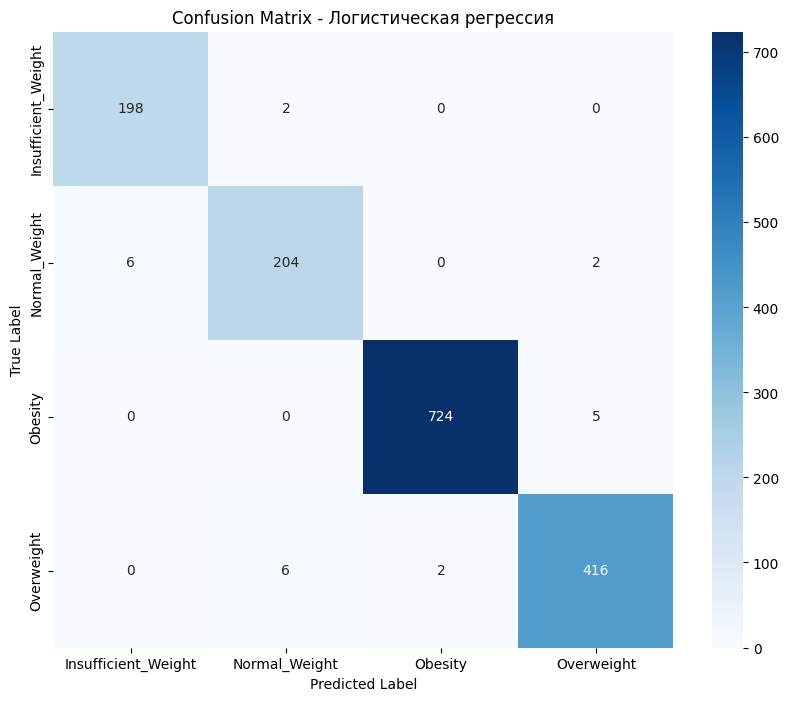

In [ ]:
make_model(logreg_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["log_reg"], result_hw, tune_logistic_regression)

## C BMI

[I 2025-12-26 12:22:37,612] A new study created in memory with name: no-name-0b20cc4b-d167-44d0-8306-cea8ba115596


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:22:37,742] Trial 0 finished with value: 0.8971355362816092 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.8971355362816092.
[I 2025-12-26 12:22:37,746] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.8971355362816092.
[I 2025-12-26 12:22:40,506] Trial 2 finished with value: 0.9777128704680086 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.9777128704680086.
[I 2025-12-26 12:22:40,520] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is tri

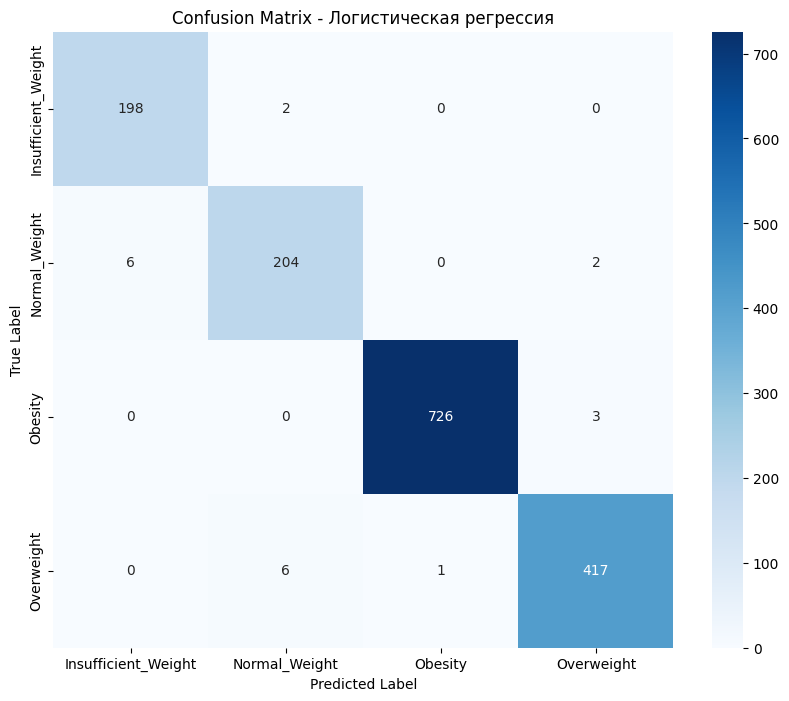

In [ ]:
make_model(logreg_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["log_reg"], result_bmi, tune_logistic_regression)

## Без BMI и без Роста и Веса

[I 2025-12-26 12:26:10,397] A new study created in memory with name: no-name-4fed27d8-5182-4858-aad0-ae53d7bf4a7d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:26:10,507] Trial 0 finished with value: 0.5681755373768703 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.5681755373768703.
[I 2025-12-26 12:26:10,510] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.5681755373768703.
[I 2025-12-26 12:26:10,949] Trial 2 finished with value: 0.5687460751094483 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.5687460751094483.
[I 2025-12-26 12:26:10,957] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is tri

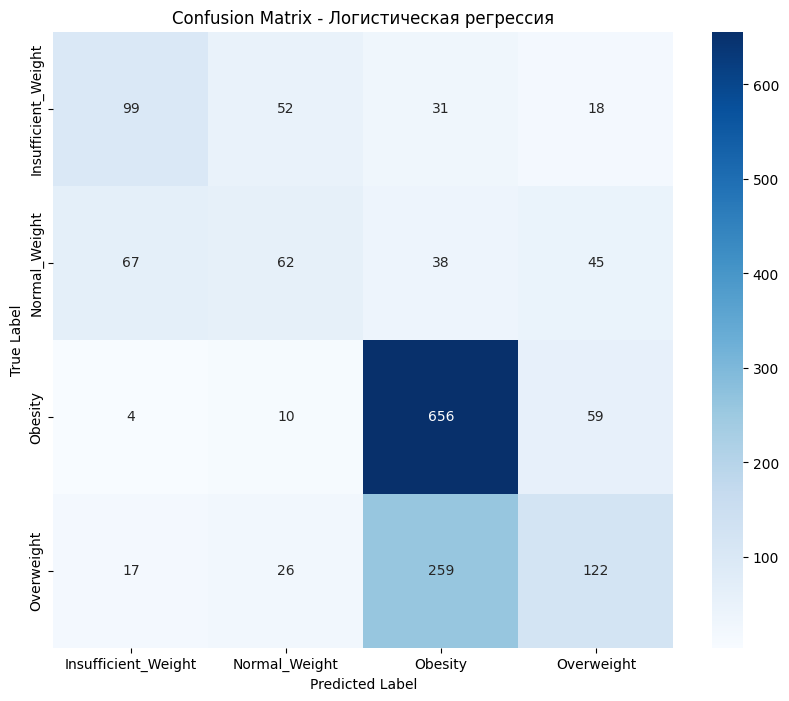

In [ ]:
make_model(logreg_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["log_reg"], result_no_anthro, tune_logistic_regression)

# **2.3. SVM**

In [ ]:
svm_pipeline = make_pipeline(
        StandardScaler(),
        SVC(random_state=42)
    )

## Без BMI

In [ ]:
make_model(svm_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["svm"], result_hw, tune_svm)

[I 2025-12-26 12:26:34,317] A new study created in memory with name: no-name-c165cb99-b002-43e3-b83d-9b065299d3a3


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:26:35,057] Trial 0 finished with value: 0.9715132417970835 and parameters: {'C': 1.3292918943162166, 'kernel': 'linear', 'class_weight': None}. Best is trial 0 with value: 0.9715132417970835.
[I 2025-12-26 12:26:35,491] Trial 1 finished with value: 0.9492156511405742 and parameters: {'C': 0.14936568554617632, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9715132417970835.
[I 2025-12-26 12:26:36,820] Trial 2 finished with value: 0.9802763431398135 and parameters: {'C': 31.428808908401084, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.9802763431398135.
[I 2025-12-26 12:26:37,420] Trial 3 finished with value: 0.9131067386937738 and parameters: {'C': 1.976218934028007, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma_float': 0.4561243772186142, 'gamma': 'scale'}. Best is trial 2 with value: 0.9802763431398135.
[W 2025-12-26 12:26:37,425] Trial 4 failed with parameters: {'C': 5.9874749104613985, 'kernel': 

ValueError: CategoricalDistribution does not support dynamic value space.

## С BMI

In [ ]:
make_model(svm_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["svm"], result_bmi, tune_svm)

## Без BMI и без Роста и Веса

In [ ]:
make_model(svm_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["svm"], result_no_anthro, tune_svm)

# **2.4. Дерево решений**

In [ ]:
dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)


## Без BMI

[I 2025-12-26 12:29:38,845] A new study created in memory with name: no-name-eb7725e7-be70-41c0-96ac-040060f6cd86


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:29:39,050] Trial 0 finished with value: 0.9425317236972283 and parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 0 with value: 0.9425317236972283.
[I 2025-12-26 12:29:39,130] Trial 1 finished with value: 0.9317500336454073 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 0 with value: 0.9425317236972283.
[I 2025-12-26 12:29:39,212] Trial 2 finished with value: 0.8808993182385771 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9425317236972283.
[I 2025-12-26 12:29:39,305] Trial 3 finished with value: 0.8908881453658252 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0

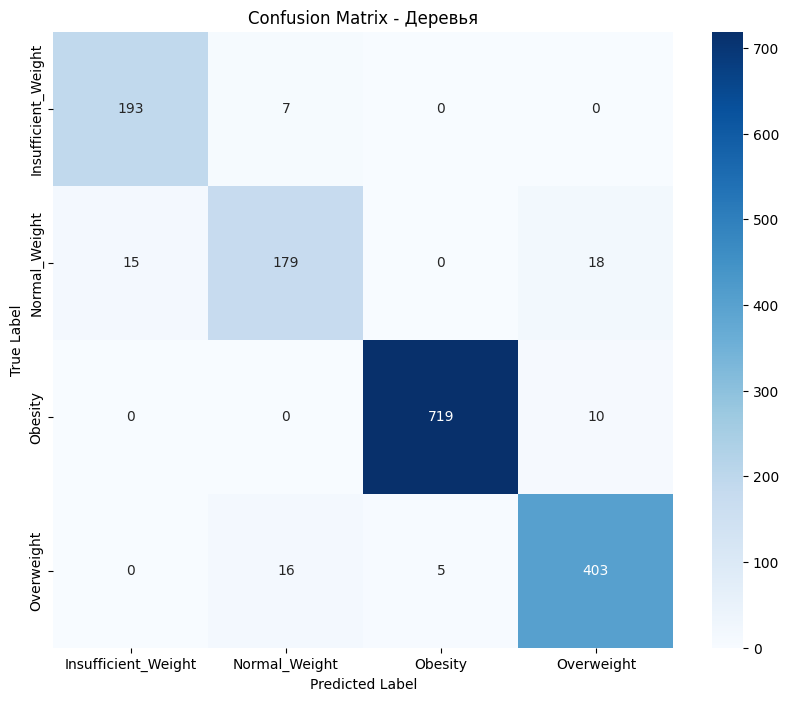

In [ ]:
make_model(dt_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["tree"], result_hw, tune_decision_tree)

## C BMI

[I 2025-12-26 12:29:45,177] A new study created in memory with name: no-name-fe526106-9262-416a-879d-494d8960b5db


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:29:45,276] Trial 0 finished with value: 0.9845948548690355 and parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 0 with value: 0.9845948548690355.
[I 2025-12-26 12:29:45,721] Trial 1 finished with value: 0.9891620263862472 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 1 with value: 0.9891620263862472.
[I 2025-12-26 12:29:45,803] Trial 2 finished with value: 0.9891620263862472 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9891620263862472.
[I 2025-12-26 12:29:45,880] Trial 3 finished with value: 0.9891620263862472 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 1 with value: 0

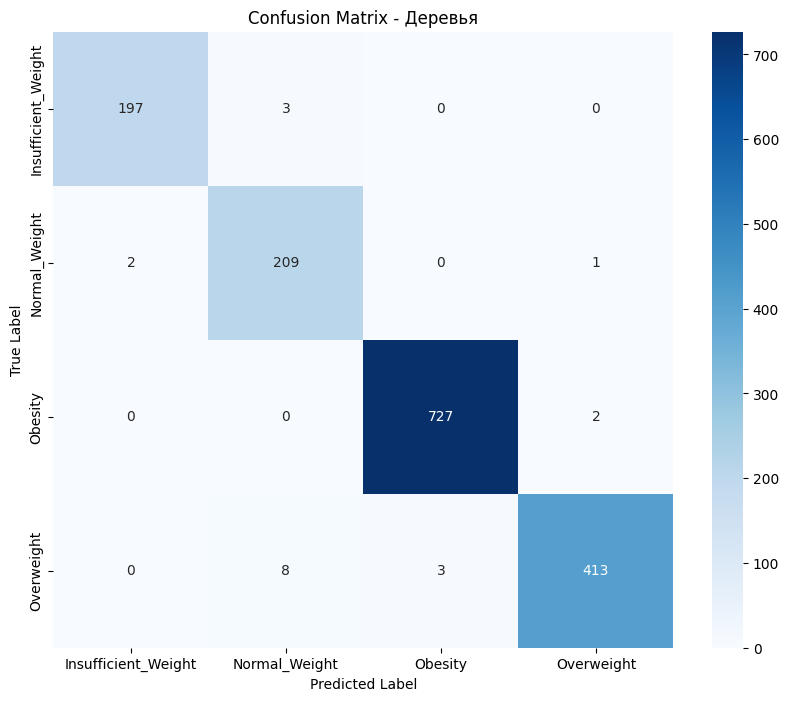

In [ ]:
make_model(dt_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["tree"], result_bmi, tune_decision_tree)

## Без BMI и без Роста и Веса

[I 2025-12-26 12:29:50,374] A new study created in memory with name: no-name-ff5c8b1b-ad76-48ee-be88-02b426cadcea


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:29:50,476] Trial 0 finished with value: 0.7258902028981226 and parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 0 with value: 0.7258902028981226.
[I 2025-12-26 12:29:50,554] Trial 1 finished with value: 0.696203466918405 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 0 with value: 0.7258902028981226.
[I 2025-12-26 12:29:50,636] Trial 2 finished with value: 0.5882048407978484 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7258902028981226.
[I 2025-12-26 12:29:50,722] Trial 3 finished with value: 0.5703220353984432 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.

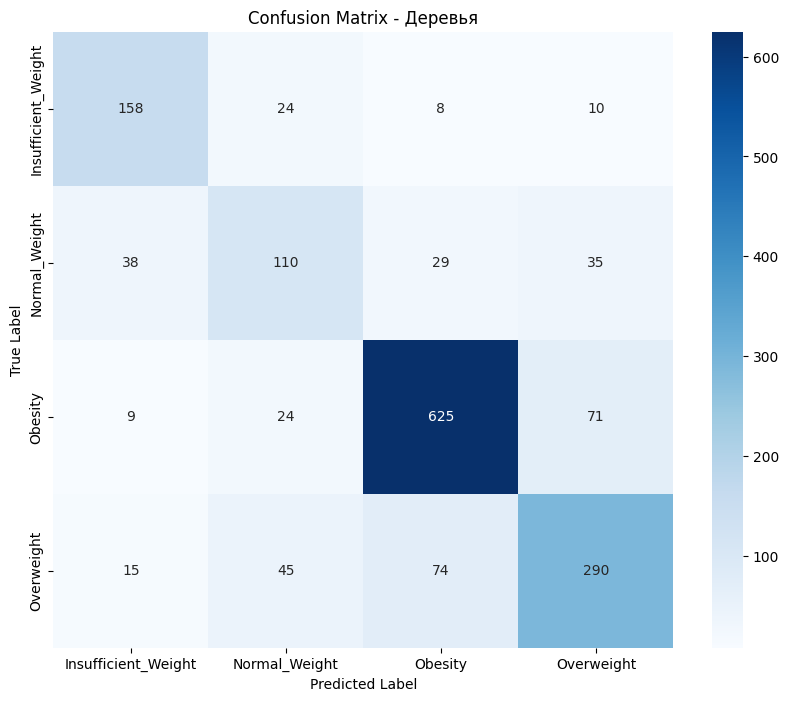

In [ ]:
make_model(dt_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["tree"], result_no_anthro, tune_decision_tree)

# **2.5. Бэггинг (Random Forest)**

In [ ]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(random_state=42)
)

## Без BMI

[I 2025-12-26 12:29:55,469] A new study created in memory with name: no-name-78556f23-bc0a-42b0-8a21-ede55c2cb10a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:29:58,290] Trial 0 finished with value: 0.9530413756031303 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.9530413756031303.
[I 2025-12-26 12:30:02,175] Trial 1 finished with value: 0.9288260668443482 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.9530413756031303.
[I 2025-12-26 12:30:03,935] Trial 2 finished with value: 0.9634587411431506 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 2 with value: 0.9634587411431506.
[I 2025-12-26 12:30:09,888] Trial 3 finished with value: 0.9533691229559965 and parameters: {'n_estimators': 500, 'cri

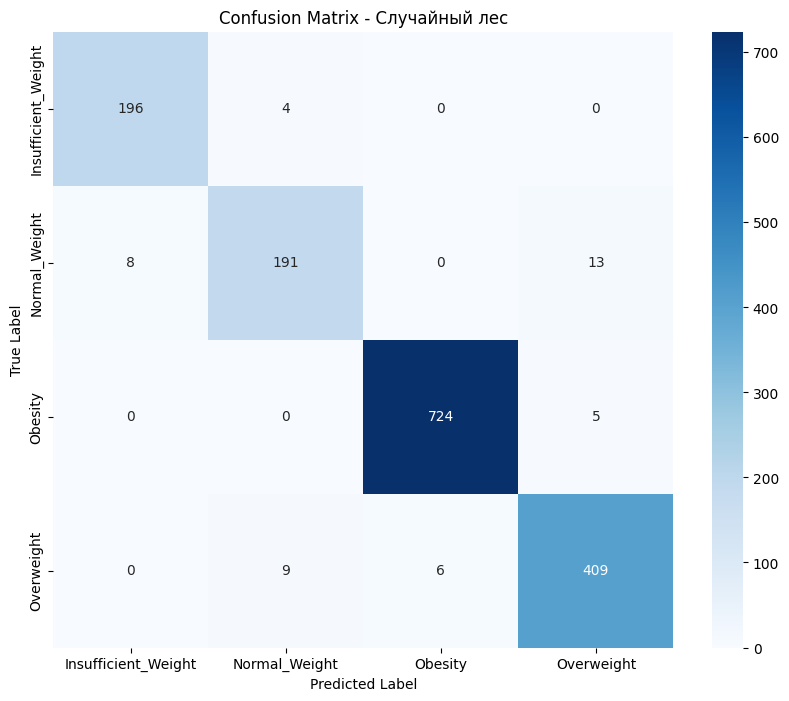

In [ ]:
make_model(rf_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["rf"], result_hw, tune_random_forest)

## С BMI

[I 2025-12-26 12:32:29,647] A new study created in memory with name: no-name-59e3e86b-30d9-44f8-9425-db3315afe5d7


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:32:31,165] Trial 0 finished with value: 0.989795085883693 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.
[I 2025-12-26 12:32:36,050] Trial 1 finished with value: 0.9872140038201005 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.
[I 2025-12-26 12:32:37,344] Trial 2 finished with value: 0.9885153734337818 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.
[I 2025-12-26 12:32:41,377] Trial 3 finished with value: 0.9891620263862472 and parameters: {'n_estimators': 500, 'criteri

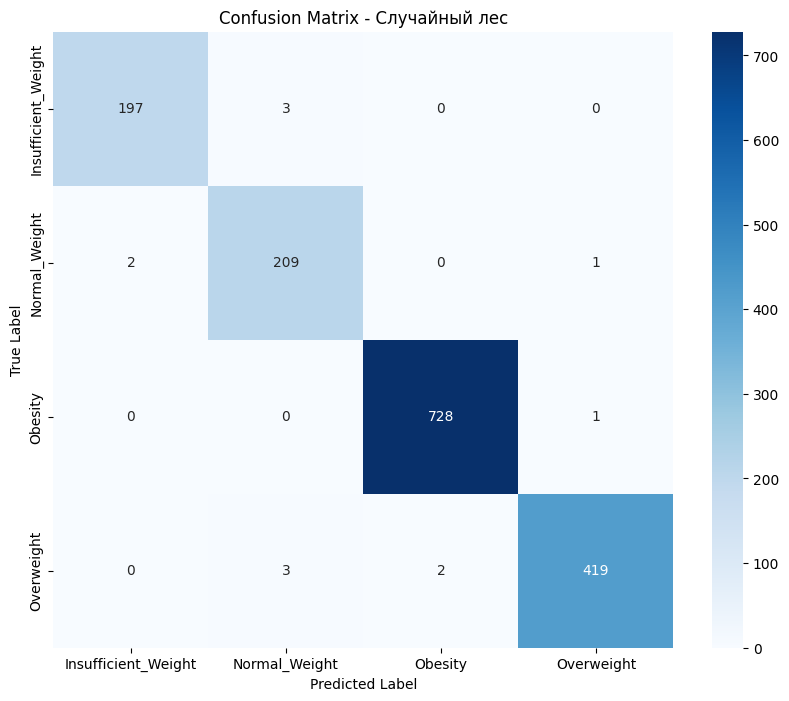

In [ ]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi, tune_random_forest)

## Без BMI и без Роста и Веса

[I 2025-12-26 12:34:31,339] A new study created in memory with name: no-name-b5ae86ac-711d-4623-b8a4-9031637d53a9


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 12:34:33,625] Trial 0 finished with value: 0.8096952594568861 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.
[I 2025-12-26 12:34:37,210] Trial 1 finished with value: 0.7127871367200824 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.
[I 2025-12-26 12:34:39,044] Trial 2 finished with value: 0.7898133282123873 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.
[I 2025-12-26 12:34:44,507] Trial 3 finished with value: 0.7747021052052913 and parameters: {'n_estimators': 500, 'cri

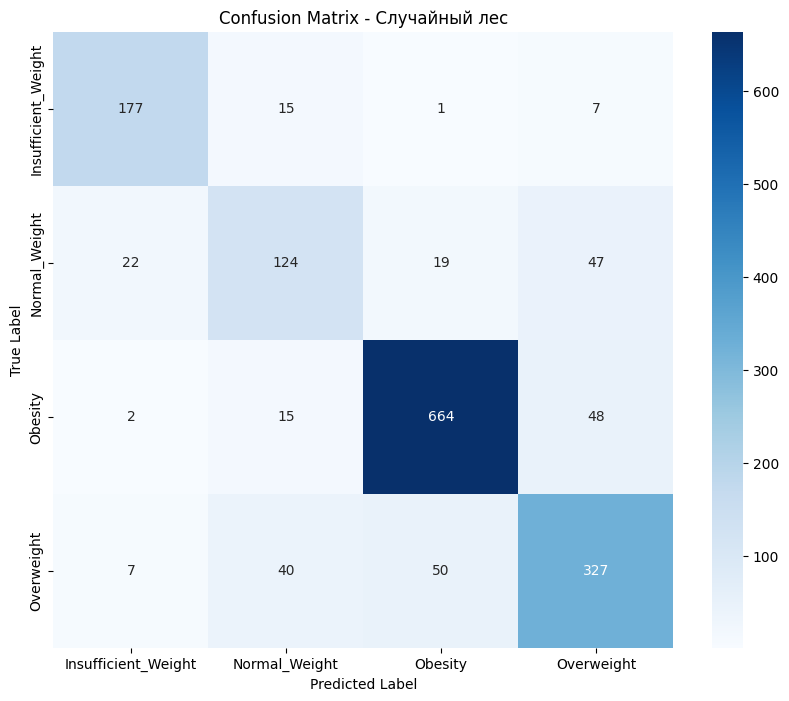

In [ ]:
make_model(rf_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["rf"], result_no_anthro, tune_random_forest)

# **2.6. Стекинг**

In [ ]:
estimators = [
    ('logreg', logreg_pipeline),
    ('svm', svm_pipeline),
    ('rf', rf_pipeline),
    ('dt', dt_pipeline)
]

final_estimator = LogisticRegression()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

stacking

StackingClassifier(cv=5,
                   estimators=[('logreg',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression(random_state=42))])),
                               ('svm',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(random_state=42))])),
                               ('rf',
                                Pipeline(steps=[('randomforestclassifier',
                                                 RandomForestClassifier(random_state=42))])),
                               ('dt',
                                Pipeline(steps=[('decisiontreeclassifier',
                                                 DecisionTreeClassifier(random_state=42))]))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

## Без BMI

[I 2025-12-26 12:36:34,220] A new study created in memory with name: no-name-4acee2d3-a686-40f1-951a-a5016dffff27


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-26 12:36:38,709] Trial 0 finished with value: 0.9597981166965486 and parameters: {'C': 1.3292918943162166, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1312}. Best is trial 0 with value: 0.9597981166965486.
[I 2025-12-26 12:36:43,930] Trial 1 finished with value: 0.9534350980121339 and parameters: {'C': 0.14936568554617632, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 2940}. Best is trial 0 with value: 0.9597981166965486.
[I 2025-12-26 12:36:49,759] Trial 2 finished with value: 0.962013633504574 and parameters: {'C': 31.428808908401084, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced', 'max_iter': 2050}. Best is trial 2 with value: 0.962013633504574.
[I 2025-12-26 12:36:54,206] Trial 3 finished with value: 0.9582948170665281 and parameters: {'C': 1.976218934028007, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1733}. Best is trial 2 with value: 0.962013633504574.
[I 2025-12-26 12:37:

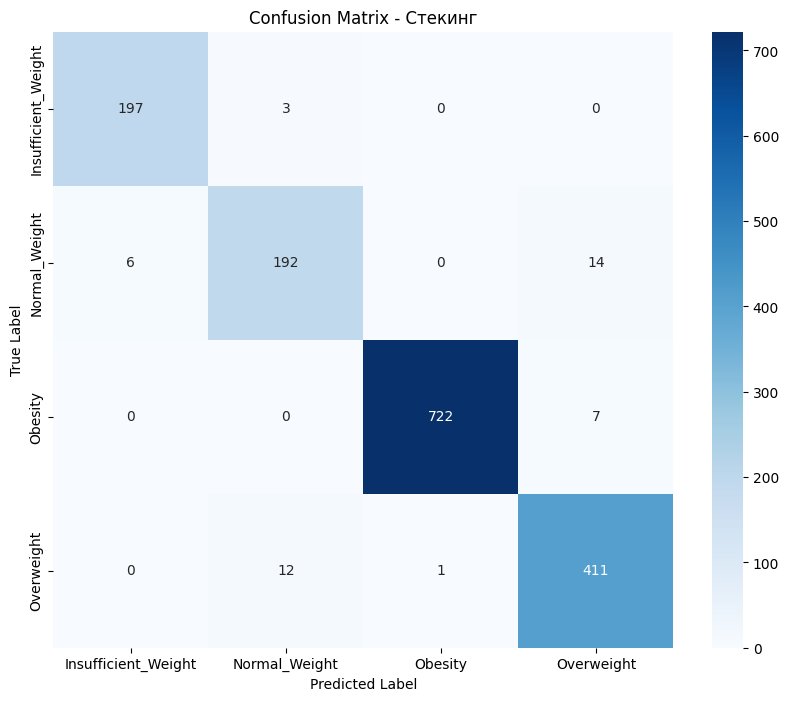

In [ ]:
make_model(stacking, X_HW_train, Y_HW_train, MODEL_NAMES["stacking"], result_hw, tune_stacking)

## C BMI

In [ ]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi, tune_stacking)

[I 2025-12-26 12:39:40,825] A new study created in memory with name: no-name-12acd25c-dc67-488a-bcfb-72726041a643


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-26 12:39:45,128] Trial 0 finished with value: 0.9879135989778242 and parameters: {'C': 1.3292918943162166, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1312}. Best is trial 0 with value: 0.9879135989778242.
[W 2025-12-26 12:39:48,528] Trial 1 failed with parameters: {'C': 0.14936568554617632, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 2940} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-3097081755.py", line 64, in <lambda>
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=30, show_progress_bar=True)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3097081755.py", line 56, in objective
    scores = cross_val_score(pipeli

KeyboardInterrupt: 

## Без BMI и без Роста и Веса

In [ ]:
make_model(stacking, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["stacking"], result_no_anthro, tune_stacking)

# **2.7. Бустинг (CatBoost)**

In [413]:
cbreg = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

In [414]:
make_catboost_model(cbreg, X_HW_cat_train, Y_HW_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_hw, tune_catboost)

[I 2025-12-26 13:43:22,391] A new study created in memory with name: no-name-da9b0cd4-204d-4dd4-8c1e-8b79b596aedb


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-12-26 13:43:26,480] Trial 0 finished with value: 0.0 and parameters: {'balance': 'Balanced', 'learning_rate': 0.1205712628744377, 'depth': 8, 'l2_leaf_reg': 2.5361081166471375e-07, 'border_count': 66}. Best is trial 0 with value: 0.0.
[I 2025-12-26 13:43:30,286] Trial 1 finished with value: 0.0 and parameters: {'balance': 'Balanced', 'learning_rate': 0.07725378389307355, 'depth': 8, 'l2_leaf_reg': 1.5320059381854043e-08, 'border_count': 249}. Best is trial 0 with value: 0.0.
[I 2025-12-26 13:43:30,303] Trial 2 finished with value: -1.0 and parameters: {'balance': None, 'learning_rate': 0.01855998084649059, 'depth': 5, 'l2_leaf_reg': 5.472429642032198e-06, 'border_count': 149}. Best is trial 0 with value: 0.0.
[I 2025-12-26 13:43:30,316] Trial 3 finished with value: -1.0 and parameters: {'balance': None, 'learning_rate': 0.08012737503998542, 'depth': 4, 'l2_leaf_reg': 4.258943089524393e-06, 'border_count': 114}. Best is trial 0 with value: 0.0.
[I 2025-12-26 13:43:32,773] Trial 

In [ ]:
make_catboost_model(cbreg, X_BMI_cat_train, Y_BMI_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_bmi)

## Без BMI и без Роста и Веса

In [ ]:
make_catboost_model(cbreg, X_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_no_anthro)

# **3.1. Таблицы сравнений**

Итак, выведем полученные значения из наших моделей:

In [411]:
print("\n### 1.  Результаты без показателя BMI (Рост/Вес включены)")
display_formatted_table(result_hw)
print("\n### 2.  Результаты c показателем BMI (Рост/Вес не включены)")
display_formatted_table(result_bmi)
print("\n### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)")
display_formatted_table(result_no_anthro)


### 1.  Результаты без показателя BMI (Рост/Вес включены)
Ошибка: В результатах отсутствует колонка для сортировки по F1-метрике ('F1-Score'). Сортировка пропущена.


,F1,ACCURACY,LogLoss,RECALL,PRECISION,ROC_AUC,TIME
CatBoost,0.9469,0.9469,0.1702,NaN,NaN,NaN,4.8484



### 2.  Результаты c показателем BMI (Рост/Вес не включены)
Словарь результатов пуст.

### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)
Словарь результатов пуст.


## **Какие же данные лучше всего использовать в дальнейшем?**
Сравнивая таблицы сравнений между собой можно сделать вывод, что **Данные С BMI** улучшают модель, чем без нее, а без признаков о весе и росте вычисления становятся в разы хуже



In [ ]:
print("Результаты c показателем BMI (Рост/Вес включены)")
display_formatted_table(result_bmi)

## **Какую модель мы выберем для дальнейшего развития?**
Даже среди трех разных данных, то лучший результат по точности показал **Стекинг**, находясь всегда на первом месте.

Однако, так как мы выбрали одни данные на которых далее будем развивать нашу модель, то кандитатом на выбор модели является **Случайный лес** за счет его скорости и не сильного отстования по точности.

# **3.2 Сравнения двух лучших моделей**

Для выбранных моделей выведем кросс-валидацию, обучение на тестовой выборки

In [ ]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi)

display_final_model_evaluation(stacking, X_BMI_train, Y_BMI_train, X_BMI_test, Y_BMI_test, MODEL_NAMES["stacking"])

In [ ]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi)

display_final_model_evaluation(rf_pipeline, X_BMI_train, Y_BMI_train, X_BMI_test, Y_BMI_test, MODEL_NAMES["rf"])

Так как значения у двух моделей совпадают, то можно предположить, что переобучение отсуствует

# **3.3 Выводы**

В данном ноутбуке были проведены обучение 6-и базовых моделей на кросс-валидации и их сравнения для получения модели, которую будем использовать в дальнейшим для ее улучшения. Кандитатами на данную роль являются **Случайный лес** и **Стекинг**.

Точно нельзя сказать, какая модель лучше: **Случайный лес** запускается быстрее, однако **Стекинг** выполняется более точным. Поэтому дальнейшую модель стоит выбирать в зависимости от ресурсов и целей, которых хотим добиться.